#Importing Data

In [32]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


drive.mount("/content/drive")
path = '/content/drive/My Drive/crime/communities.data'

df = pd.read_csv(path, header=None, na_values='?')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [33]:
with open('/content/drive/My Drive/crime/communities.names', 'r') as f:
    print(f.read())

Title: Communities and Crime

Abstract: Communities within the United States. The data combines socio-economic data 
from the 1990 US Census, law enforcement data from the 1990 US LEMAS survey, and crime 
data from the 1995 FBI UCR.

-----------------------------------------------------------------------------------------

Data Set Characteristics:  Multivariate
Attribute Characteristics: Real
Associated Tasks: Regression
Number of Instances: 1994
Number of Attributes: 128
Missing Values? Yes
Area: Social
Date Donated: 2009-07-13

-----------------------------------------------------------------------------------------

Source:

Creator: Michael Redmond (redmond 'at' lasalle.edu); Computer Science; La Salle 
University; Philadelphia, PA, 19141, USA
-- culled from 1990 US Census, 1995 US FBI Uniform Crime Report, 1990 US Law 
Enforcement Management and Administrative Statistics Survey, available from ICPSR at U 
of Michigan.
-- Donor: Michael Redmond (redmond 'at' lasalle.edu); Computer

#Data cleaning

In [34]:
df_clean = df.drop(columns=[0, 1, 2, 3, 4])
threshold = len(df_clean) * 0.5
df_clean = df_clean.dropna(thresh=threshold, axis=1)
# fulfilling the data with median value
df_clean = df_clean.fillna(df_clean.median())
X = df_clean.iloc[:, :-1]
y = df_clean.iloc[:, -1]

print(f"The amount of columns after cleaning:  {X.shape[1]}")

The amount of columns after cleaning:  100


#Train test split


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train data: {X_train.shape[0]} rows")
print(f"Test data: {X_test.shape[0]} rows")

Train data: 1495 rows
Test data: 499 rows


#Multi-layer-perceptron


In [36]:
# activation='relu': Rectified Linear Unit, standard for deep learning
# solver='adam': Effective optimizer for medium to large datasets
# max_iter=1000: Maximum number of iterations for the solver to converge
mlp = MLPRegressor(hidden_layer_sizes=(64, 32),
                   activation='relu',
                   solver='adam',
                   max_iter=1000,
                   random_state=42)

# train the model using the training data
mlp.fit(X_train, y_train)

# make predictions using the test data
y_pred_mlp = mlp.predict(X_test)

# evaluate the model performance
mse = mean_squared_error(y_test, y_pred_mlp)
r2 = r2_score(y_test, y_pred_mlp)

print(f"--- Neural Network (MLP) Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_mlp):.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Neural Network (MLP) Evaluation ---
Mean Squared Error (MSE): 0.0185
Mean Absolute Error (MAE): 0.0922
R-squared (R2) Score: 0.6187


# MLP Visualization

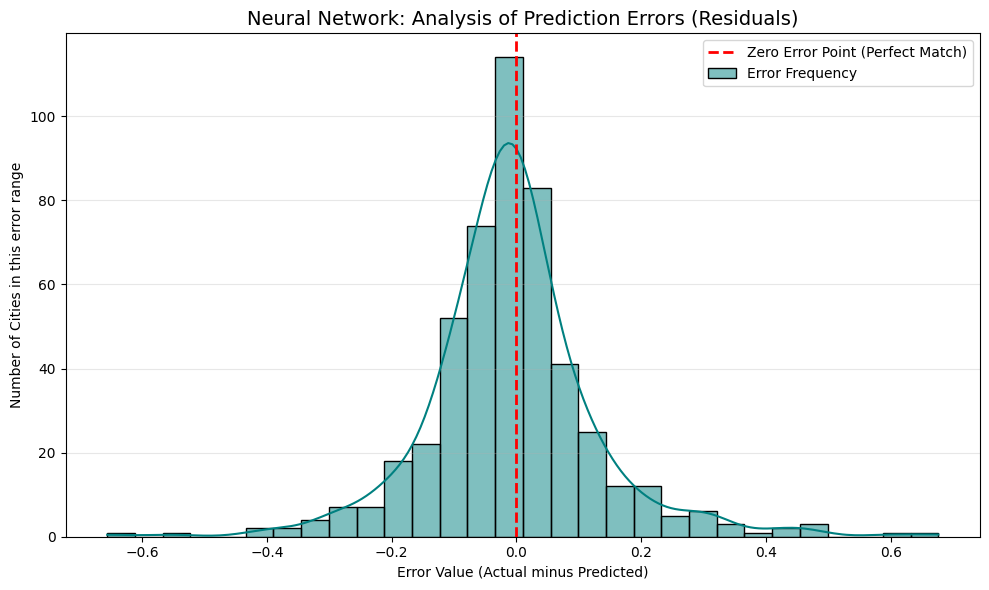

In [37]:
errors = y_test - y_pred_mlp

plt.figure(figsize=(10, 6))
# Plotting the histogram with a KDE line (trend line)
sns.histplot(errors, kde=True, color='teal', bins=30, label='Error Frequency')

# Drawing the vertical line at 0 error
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error Point (Perfect Match)')

plt.title('Neural Network: Analysis of Prediction Errors (Residuals)', fontsize=14)
plt.xlabel('Error Value (Actual minus Predicted)')
plt.ylabel('Number of Cities in this error range')

# Adding the legend to explain the colors and lines
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#Random Forest


In [38]:
# Training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
print("--- Random Forest Performance ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"R-squared Score (R2): {r2_score(y_test, y_pred_rf):.4f}")

--- Random Forest Performance ---
Mean Squared Error (MSE): 0.0173
Mean Absolute Error (MAE): 0.0921
R-squared Score (R2): 0.6449


#Random Forest Visualization

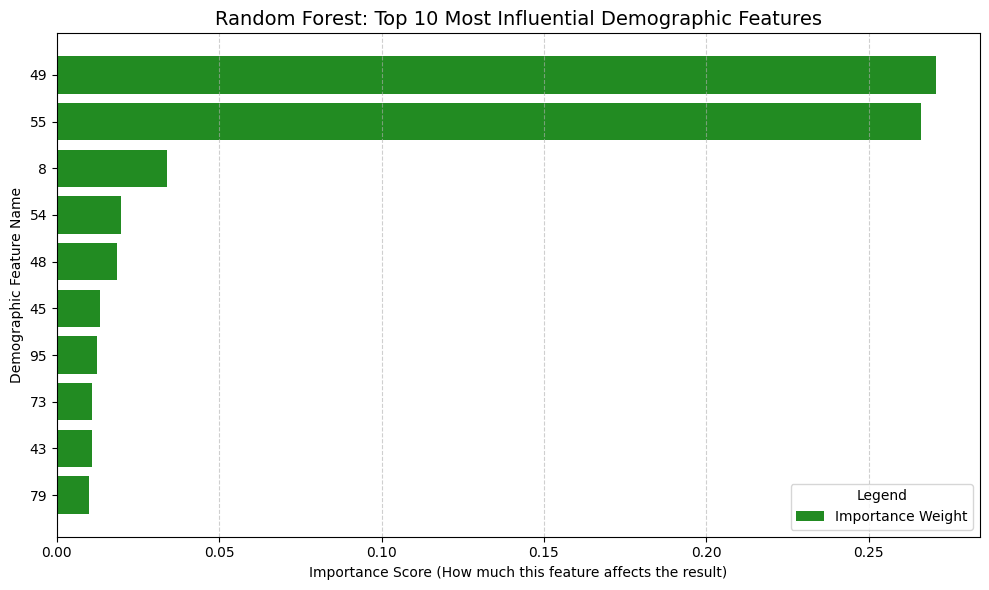

In [39]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
# Adding a label for the legend
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center', label='Importance Weight')

plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Random Forest: Top 10 Most Influential Demographic Features', fontsize=14)
plt.xlabel('Importance Score (How much this feature affects the result)')
plt.ylabel('Demographic Feature Name')

# Adding the legend to explain the bars
plt.legend(loc='lower right', title='Legend')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#XGBOOST


In [40]:
# training
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# predictions
y_pred_xgb = xgb_model.predict(X_test)

# evaluation metrics
print("--- XGBoost Performance ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_xgb):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"R-squared Score (R2): {r2_score(y_test, y_pred_xgb):.4f}")

--- XGBoost Performance ---
Mean Squared Error (MSE): 0.0180
Mean Absolute Error (MAE): 0.0905
R-squared Score (R2): 0.6305


#XGBoost Visualization

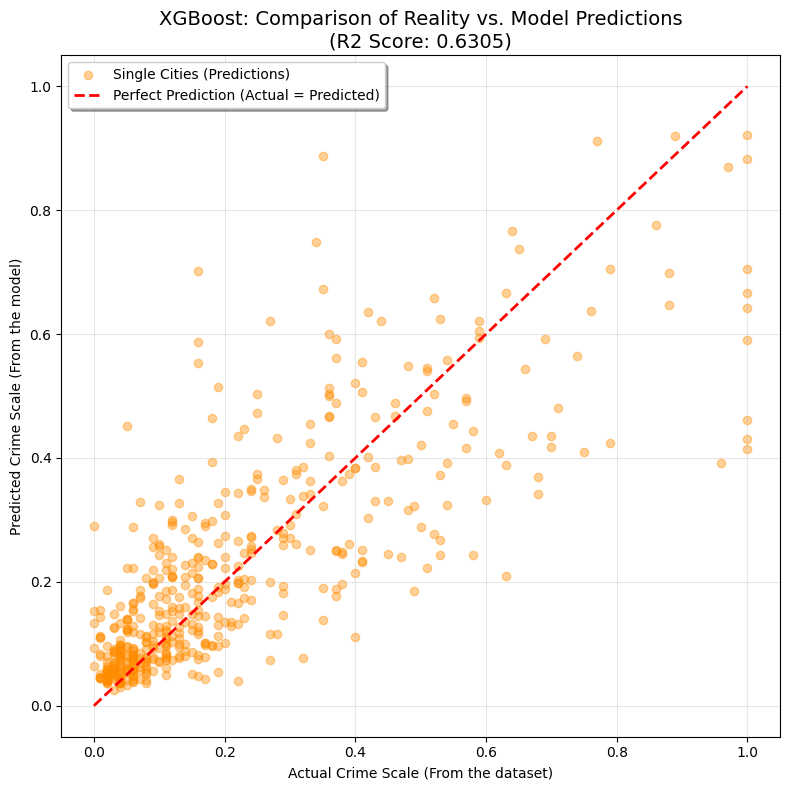

In [41]:
plt.figure(figsize=(8, 8))

# Scatter plot for predictions
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='darkorange', label='Single Cities (Predictions)')

# Perfect prediction line
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Perfect Prediction (Actual = Predicted)')

plt.title(f'XGBoost: Comparison of Reality vs. Model Predictions\n(R2 Score: {r2_score(y_test, y_pred_xgb):.4f})', fontsize=14)
plt.xlabel('Actual Crime Scale (From the dataset)')
plt.ylabel('Predicted Crime Scale (From the model)')

# Adding the legend to identify the dots and the line
plt.legend(loc='upper left', shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()